# Notebook 2: Churn Modelling and Retention Strategy

This notebook builds on the SQL and exploratory business analysis completed in Notebook 1.

The objective is to build a machine learning model that predicts customer churn and then convert the model outputs into a business-focused retention strategy.

The modelling workflow includes feature selection, preprocessing, model training, model evaluation, churn probability scoring, and retention prioritisation using customer value.

In [2]:
# ============================================================
# Telecom Customer Churn Project
# Notebook 02: Modelling and Retention Strategy
# ============================================================

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

###

## Loading the dataset

In [4]:
file_path = "/Users/alankar/Desktop/Projects/Telecom Retention Analytics/data/processed/Telco_customer_churn.csv"
df = pd.read_csv(file_path)

df

,customerid,count,country,state,city,zip_code,lat_long,latitude,longitude,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv,churn_reason,tenure_group
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,1-12 months
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,1-12 months
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved,1-12 months
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,25-48 months
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices,49-72 months
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,No,0,45,5306,NaN,49-72 months
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,0,59,2140,NaN,13-24 months
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,0,71,5560,NaN,49-72 months
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN,1-12 months


In [5]:
print(f"No. of rows = {df.shape[0]}")
print(f"No. of columns = {df.shape[1]}")

No. of rows = 7043
No. of columns = 34


In [6]:
df.columns.tolist()

['customerid',
 'count',
 'country',
 'state',
 'city',
 'zip_code',
 'lat_long',
 'latitude',
 'longitude',
 'gender',
 'senior_citizen',
 'partner',
 'dependents',
 'tenure_months',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract',
 'paperless_billing',
 'payment_method',
 'monthly_charges',
 'total_charges',
 'churn_label',
 'churn_value',
 'churn_score',
 'cltv',
 'churn_reason',
 'tenure_group']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerid         7043 non-null   object 
 1   count              7043 non-null   int64  
 2   country            7043 non-null   object 
 3   state              7043 non-null   object 
 4   city               7043 non-null   object 
 5   zip_code           7043 non-null   int64  
 6   lat_long           7043 non-null   object 
 7   latitude           7043 non-null   float64
 8   longitude          7043 non-null   float64
 9   gender             7043 non-null   object 
 10  senior_citizen     7043 non-null   object 
 11  partner            7043 non-null   object 
 12  dependents         7043 non-null   object 
 13  tenure_months      7043 non-null   int64  
 14  phone_service      7043 non-null   object 
 15  multiple_lines     7043 non-null   object 
 16  internet_service   7043 

##

## Confirming target distribution

In [8]:
target_counts = df["churn_value"].value_counts().reset_index()
target_counts.columns = ["churn_value", "customer_count"]

target_counts

,churn_value,customer_count
0,0,5174
1,1,1869


In [9]:
churn_rate = df["churn_value"].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")

Overall churn rate: 26.54%


The target variable for this modelling task is `churn_value`, where 1 indicates that a customer churned and 0 indicates that the customer stayed.

The dataset has an overall churn rate of approximately 26.54%. This means the target variable is moderately imbalanced. As a result, model evaluation should not rely only on accuracy. Metrics such as recall, precision, F1-score, ROC-AUC, and the confusion matrix are also important.

###

## Modelling-focused EDA

### 1. Correlation matrix

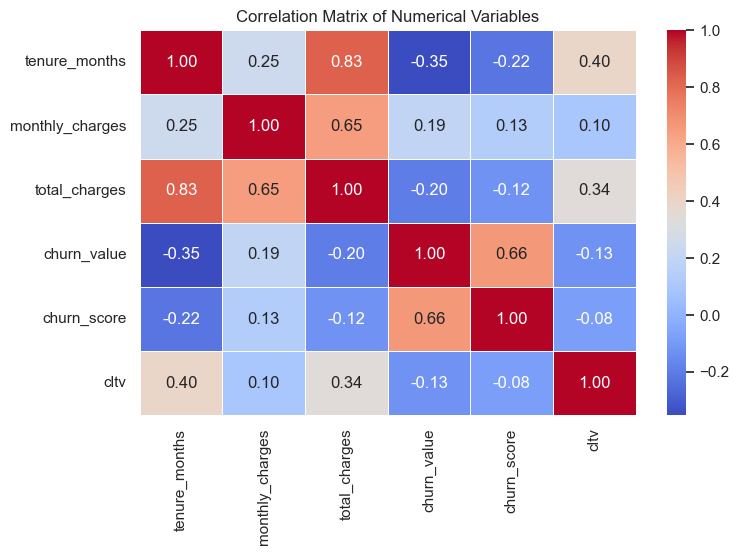

In [10]:
numeric_cols = [
    "tenure_months",
    "monthly_charges",
    "total_charges",
    "churn_value",
    "churn_score",
    "cltv"
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

### Insight: Numerical Correlation Matrix

The correlation matrix shows the relationships between the main numerical variables in the dataset.

`tenure_months` and `total_charges` have a strong positive correlation of **0.83**, which is expected because customers with longer tenure naturally accumulate higher total charges over time. `monthly_charges` and `total_charges` also show a moderate positive correlation of **0.65**, suggesting that customers with higher monthly bills tend to accumulate higher total spend.

From a churn perspective, `tenure_months` has a negative correlation with churn of **-0.35**, indicating that customers with longer tenure are less likely to churn. `total_charges` also has a negative correlation with churn of **-0.20**, which is likely linked to the same tenure effect. In contrast, `monthly_charges` has a positive correlation with churn of **0.19**, suggesting that customers paying higher monthly charges may be more likely to leave.

`cltv` has a weak negative correlation with churn of **-0.13**, indicating that higher-value customers may be slightly less likely to churn, although the relationship is not strong on its own.

#

### 2. Correlation with Churn

In [11]:
target_corr = (
    corr_matrix["churn_value"]
    .drop("churn_value")
    .sort_values()
    .reset_index()
)

target_corr.columns = ["feature", "correlation_with_churn"]

target_corr

,feature,correlation_with_churn
0,tenure_months,-0.352229
1,total_charges,-0.198324
2,cltv,-0.127463
3,monthly_charges,0.193356
4,churn_score,0.664897


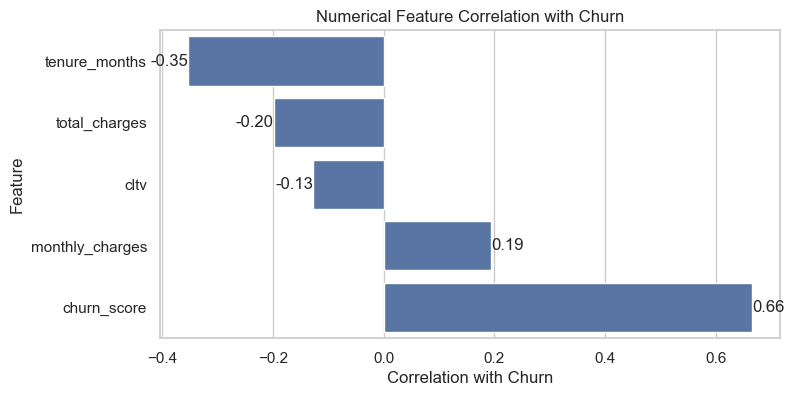

In [12]:
plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=target_corr,
    x="correlation_with_churn",
    y="feature"
)

plt.title("Numerical Feature Correlation with Churn")
plt.xlabel("Correlation with Churn")
plt.ylabel("Feature")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.show()

### Leakage Note: Churn Score

`churn_score` shows a strong positive correlation with `churn_value` of **0.66**. However, this column was generated using IBM’s predictive modelling tool and already represents an estimated churn risk score.

Because of this, `churn_score` would create data leakage if included as an input feature. It would make the model appear unrealistically strong because it already contains information derived from churn prediction.

Therefore, `churn_score` is excluded from the modelling features. It is kept here only to demonstrate why leakage prevention is important.

### Insight: Correlation with Churn

The target-correlation chart shows that `tenure_months` has the strongest valid numerical relationship with churn, with a correlation of **-0.35**. This supports the earlier business finding that newer customers are more likely to churn, while long-tenure customers are more stable.

`monthly_charges` has a positive correlation with churn of **0.19**, suggesting that customers with higher monthly bills may have greater churn risk. This could be linked to price sensitivity, perceived value, or competitor offers.

`total_charges` has a negative correlation with churn of **-0.20**, but this should be interpreted carefully because total charges are strongly influenced by tenure. Customers with high total charges are often long-tenure customers, and longer tenure is associated with lower churn.

`cltv` has a weaker negative relationship with churn, suggesting that customer value alone may not be enough to predict churn but can still be useful later when prioritising retention actions.

The strongest correlation overall is `churn_score`, but this is excluded from modelling because it would cause data leakage.

#

### 3. Churn Status (Monthly Charge vs Tenure Months)

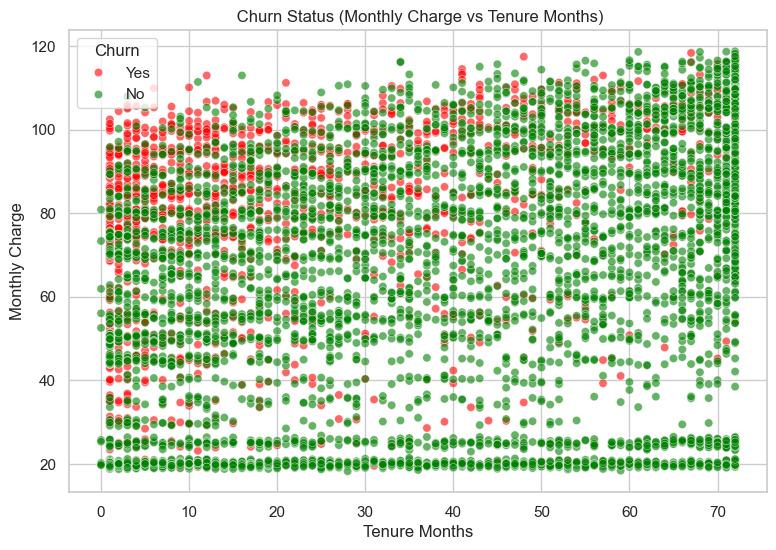

In [13]:
custom_colours = {"Yes":"Red", "No":"Green"}

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="tenure_months",
    y="monthly_charges",
    hue="churn_label",
    palette = custom_colours,
    alpha=0.6
)

plt.title(" Churn Status (Monthly Charge vs Tenure Months)")
plt.xlabel("Tenure Months")
plt.ylabel("Monthly Charge")
plt.legend(title="Churn")
plt.show()

### Insight: Churn Status (Monthly Charge vs Tenure Months)

The scatterplot shows the relationship between customer tenure, monthly charges, and churn status. Churned customers are more concentrated among customers with shorter tenure, especially in the earlier months of the customer relationship.

There is also visible churn among customers with higher monthly charges, which supports the earlier finding that monthly charges are positively associated with churn. This suggests that customers who are newer and paying higher monthly fees may represent an important risk group.

As tenure increases, retained customers become more dominant, especially among customers with longer relationships with the company. This reinforces the importance of onboarding, early engagement, and first-year retention efforts.

From a modelling perspective, this visual suggests that both `Tenure_Months` and `Monthly_Charges` are likely to be useful predictive features. It also suggests that interactions between tenure and charges may help identify higher-risk customer segments.

#

### 4. Churn Heatmap (Contract Type and Internet Service)

In [14]:
contract_internet_churn = (
    df.pivot_table(
        index="contract",
        columns="internet_service",
        values="churn_value",
        aggfunc="mean"
    ) * 100
)

contract_internet_churn

internet_service,DSL,Fiber optic,No
contract,,,
Month-to-month,32.215863,54.605263,18.893130
One year,9.298246,19.294991,2.472527
Two year,1.910828,7.226107,0.783699


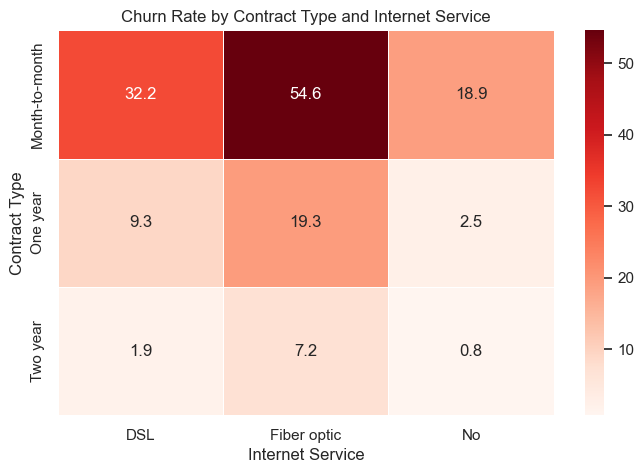

In [15]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    contract_internet_churn,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    linewidths=0.5
)

plt.title("Churn Rate by Contract Type and Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Contract Type")
plt.show()

### Insight: Churn Heatmap (Contract Type and Internet Service)

The heatmap shows that churn risk changes significantly when contract type and internet service are considered together.

The highest-risk group is **month-to-month fiber optic customers**, with a churn rate of **54.6%**. This is substantially higher than month-to-month DSL customers at **32.2%** and month-to-month customers with no internet service at **18.9%**.

The pattern also shows that longer contracts are associated with much lower churn across every internet service category. For example, fiber optic customers on two-year contracts have a churn rate of only **7.2%**, compared with **54.6%** for month-to-month fiber optic customers.

This suggests that churn is not driven by one factor alone. Instead, risk increases when certain conditions appear together, particularly flexible contracts and fiber optic service.

From a modelling perspective, this heatmap supports the use of categorical features such as `contract` and `internet_service`. It also justifies creating an engineered feature later for high-risk customer profiles, such as customers who are on month-to-month contracts and use fiber optic service.

#

## Feature Selection and Leakage Prevention

Before training the model, columns that would not be available before churn occurs must be removed. Including these variables would create data leakage and make the model appear more accurate than it would be in a real business setting.

The target variable is `Churn_Value`. Columns such as `Churn_Label`, `Churn_Score`, and `Churn_Reason` should not be used as model inputs because they either duplicate the target or contain information only known after churn.

In [16]:
leakage_and_unnecessary_cols = [
    "customerid",
    "count",
    "country",
    "state",
    "lat_long",
    "latitude",
    "longitude",
    "zip_code",
    "city",
    "churn_label",
    "churn_value",
    "churn_score",
    "churn_reason",
    "tenure_group"
]

X = df.drop(columns=leakage_and_unnecessary_cols)
y = df["churn_value"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (7043, 20)
Target shape: (7043,)


In [17]:
X.columns.tolist()

['gender',
 'senior_citizen',
 'partner',
 'dependents',
 'tenure_months',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract',
 'paperless_billing',
 'payment_method',
 'monthly_charges',
 'total_charges',
 'cltv']

Location fields such as city, zip code, latitude, and longitude were excluded from the first modelling version to keep the model focused on customer characteristics, service usage, contract type, and billing behaviour. These geographic fields remain useful for dashboarding and business analysis but are not included in the initial predictive model.

#

## Identfying Numerical and Catetorical Features

In [18]:
numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['tenure_months', 'monthly_charges', 'total_charges', 'cltv']

Categorical features:
['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method']


### Use of Categorical Features in Modelling

Categorical features were included in the modelling process because many important churn drivers are non-numeric. Variables such as contract type, payment method, internet service, tech support, online security, and billing method were shown during SQL analysis to have strong relationships with churn.

These categorical variables will be transformed using one-hot encoding so that machine learning models could use them as numerical inputs.

Columns that could cause data leakage, such as `churn_label`, `churn_score`, and `churn_reason`, were removed. Identifier, constant, and location-based columns were also excluded from the first model to keep the model focused on customer, service, and billing behaviour.

`tenure_group` was excluded from the first modelling version because it is derived from `tenure_months`. Keeping `tenure_months` preserves the original numerical information without adding a redundant grouped version of the same feature.

#

## Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining churn rate:")
print(f"{y_train.mean() * 100:.2f}%")

print("\nTest churn rate:")
print(f"{y_test.mean() * 100:.2f}%")

Training set shape: (5634, 20)
Test set shape: (1409, 20)

Training churn rate:
26.54%

Test churn rate:
26.54%


####

### Train-Test Split Validation

The dataset was split into a training set and a test set using an 80:20 ratio.

The training set contains **5,634 customers**, while the test set contains **1,409 customers**. Both sets have 20 input features after removing leakage, identifier, location, and unnecessary columns.

A stratified split was used to preserve the churn distribution across both datasets. This worked as expected:

- Training churn rate: **26.54%**
- Test churn rate: **26.54%**

The churn rates are almost identical across the training and test sets, which means the model will be trained and evaluated on datasets with the same class balance. This is important because churn is moderately imbalanced, and an unbalanced split could lead to misleading model evaluation results.

Since the churn distribution is consistent across both sets, the test set provides a fair basis for evaluating how well the model generalises to unseen customers.

## Preprocessing pipeline

In [21]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

###

## Baseline Logistic Regression Model

In [22]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure_months',
                                                   'monthly_charges',
                                                   'total_charges', 'cltv']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'senior_citizen',
                                                   'partner', 'dependents',
                                                   'phone_service',
                                                   'multiple_lines',
                                                   'internet_service',
                                                   'online_security',
                                                   'online_backup',
                                                   'device_protection',
                                                   'tech_support',
                                                   'streaming_tv',
                                                   'streaming_movies',
                                                   'contract',
                                                   'paperless_billing',
                                                   'payment_method'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [23]:
y_pred_baseline = baseline_model.predict(X_test)
y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

## Metrics for our baseline model

In [24]:
baseline_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_baseline),
    "Precision": precision_score(y_test, y_pred_baseline),
    "Recall": recall_score(y_test, y_pred_baseline),
    "F1 Score": f1_score(y_test, y_pred_baseline),
    "ROC-AUC": roc_auc_score(y_test, y_proba_baseline)
}

baseline_results_df = pd.DataFrame([baseline_results])

baseline_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.801987,0.642643,0.572193,0.605375,0.848942


## Confusion Matrix

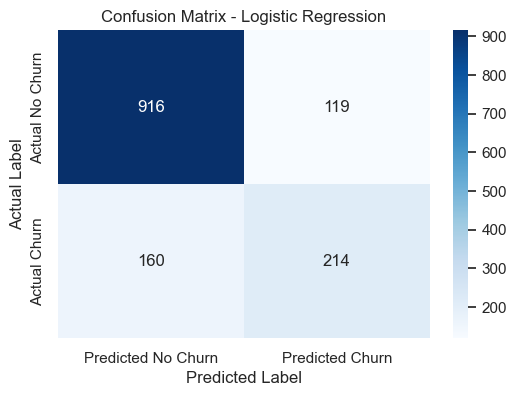

In [25]:
cm = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted No Churn", "Predicted Churn"],
    yticklabels=["Actual No Churn", "Actual Churn"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

The confusion matrix shows how many customers were correctly and incorrectly classified by the model.

For this churn problem, false negatives are especially important. A false negative occurs when the model predicts that a customer will stay, but the customer actually churns. These cases are costly because the business misses the opportunity to intervene with a retention action.

False positives are also relevant because they represent customers who are incorrectly flagged as churn risks, which could lead to unnecessary retention spending.

## Classification Report

In [26]:
print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.57      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



### Baseline Logistic Regression Results

The baseline Logistic Regression model achieved an accuracy of **80.20%** and a ROC-AUC score of **0.849**. This suggests that the model has a strong ability to distinguish between customers who churn and customers who stay.

For the churn class, the model achieved a precision of **64.26%** and a recall of **57.22%**. This means that when the model predicts a customer will churn, it is correct around 64% of the time. However, it only identifies around 57% of all actual churned customers but missed around 43% of them. Since the main business objective is to detect customers likely to churn, improving recall for class 1 should be a priority, even if it slightly reduces overall accuracy.

The confusion matrix shows that the model correctly identified **214 churned customers**, but missed **160 churned customers** by predicting them as retained. These false negatives are important from a business perspective because they represent customers who would not receive a retention intervention despite being at risk.

Overall, Logistic Regression provides a solid baseline. The ROC-AUC score is strong, but recall for churned customers could be improved. Since the business objective is to identify customers likely to leave, the next step is to compare this baseline against more flexible models such as Random Forest and Gradient Boosting.

##

## Futher Modelling and Comparison

After establishing a Logistic Regression baseline, additional classification models are trained and compared. Random Forest and Gradient Boosting are included because they can capture non-linear relationships and interactions between customer features.

All models use the same preprocessing pipeline to ensure a fair comparison.

In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        random_state=42,
        class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

model_results = []

In [28]:
for model_name, model in models.items():
    clf = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]
    
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

model_results_df = pd.DataFrame(model_results)
model_results_df.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Gradient Boosting,0.804116,0.660131,0.540107,0.594118,0.852592
1,Random Forest,0.767211,0.544402,0.754011,0.632287,0.851372
0,Logistic Regression,0.801987,0.642643,0.572193,0.605375,0.848942


## Visualising the Comparison

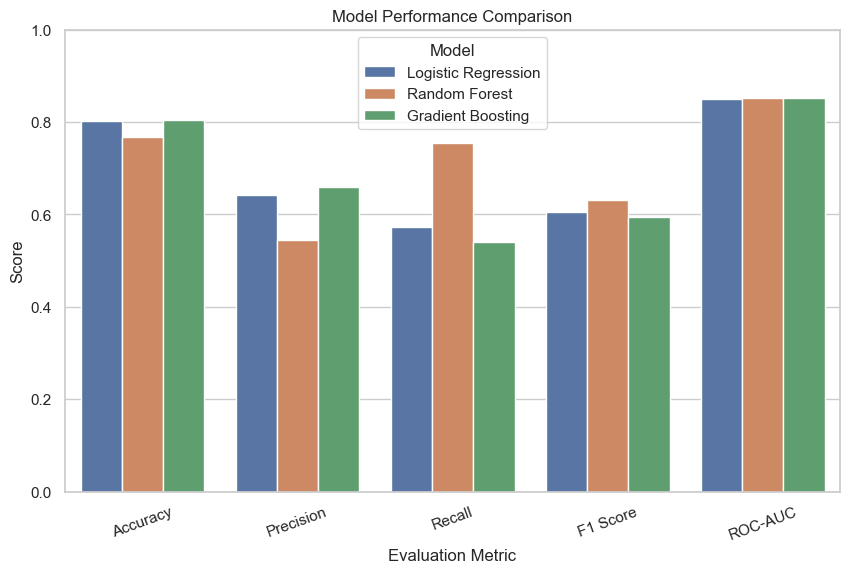

In [29]:
model_results_melted = model_results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=model_results_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Model Performance Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Model")

plt.show()

##

## Cross-Validation and Hyperparameter Tuning

The initial model comparison used default or manually selected model parameters. To improve model performance and make the model selection process more robust, hyperparameter tuning was performed using cross-validation.

Cross-validation evaluates model performance across multiple splits of the training data. This reduces dependence on a single train-test split and provides a more reliable estimate of model performance.

For this churn prediction task, Random Forest and Gradient Boosting were tuned because they are flexible ensemble models and are likely to benefit from parameter optimisation. The tuning process focuses on improving recall and ROC-AUC, since the business objective is to identify customers who are likely to churn.

## Hyperparameter Tuning for Random Forest

In [30]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

rf_param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [6, 8, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_grid_search.best_params_)

print("\nBest cross-validation recall:")
print(rf_grid_search.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Random Forest parameters:
{'model__max_depth': 6, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best cross-validation recall:
0.8107023411371237


Random Forest was tuned using cross-validation with recall as the scoring metric. Recall was prioritised because the business objective is to identify as many actual churned customers as possible. Missing churners would mean missed opportunities for retention intervention.

###

## Hyperparameter Tuning for Gradient Boosting

In [32]:
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

gb_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

gb_grid_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

gb_grid_search.fit(X_train, y_train)

print("Best Gradient Boosting parameters:")
print(gb_grid_search.best_params_)

print("\nBest cross-validation recall:")
print(gb_grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Gradient Boosting parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Best cross-validation recall:
0.5692307692307692


####

## Evaluating tuned models on test set

In [33]:
tuned_models = {
    "Tuned Random Forest": rf_grid_search.best_estimator_,
    "Tuned Gradient Boosting": gb_grid_search.best_estimator_
}

tuned_results = []

for model_name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    tuned_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned Random Forest,0.758694,0.531022,0.778075,0.631236,0.849797
1,Tuned Gradient Boosting,0.801278,0.653595,0.534759,0.588235,0.851719


## Model Comparison

In [34]:
all_model_results = pd.concat(
    [model_results_df, tuned_results_df],
    ignore_index=True
)

all_model_results.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Gradient Boosting,0.804116,0.660131,0.540107,0.594118,0.852592
4,Tuned Gradient Boosting,0.801278,0.653595,0.534759,0.588235,0.851719
1,Random Forest,0.767211,0.544402,0.754011,0.632287,0.851372
3,Tuned Random Forest,0.758694,0.531022,0.778075,0.631236,0.849797
0,Logistic Regression,0.801987,0.642643,0.572193,0.605375,0.848942


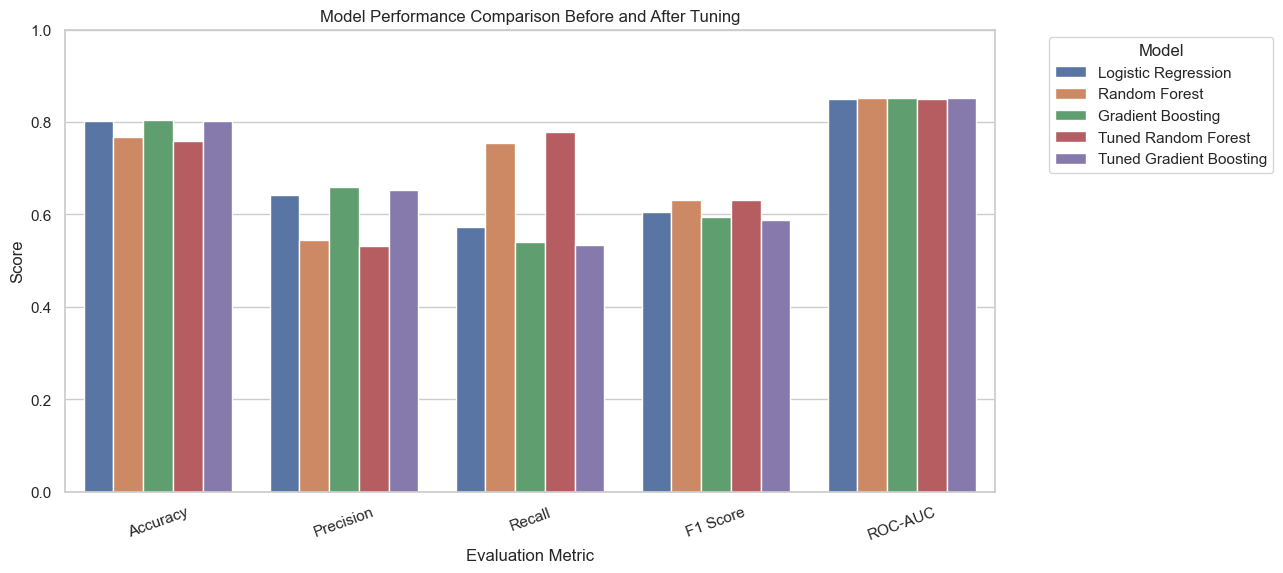

In [35]:
all_model_results_melted = all_model_results.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=all_model_results_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Model Performance Comparison Before and After Tuning")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

## Tuned Model Comparison

Hyperparameter tuning was performed for Random Forest and Gradient Boosting using cross-validation. The purpose was to test whether model performance could be improved beyond the initial model comparison.

The results show that tuning did not materially improve overall model performance. The tuned Random Forest achieved the highest recall at **77.81%**, meaning it identified the largest share of actual churned customers. However, this came with lower precision, lower accuracy, and a slightly lower ROC-AUC compared with the original Random Forest model.

The original Random Forest achieved a recall of **75.40%**, an F1-score of **0.632**, and a ROC-AUC of **0.851**. This makes it the strongest business-aligned model because it identifies a high proportion of churned customers while maintaining a slightly better balance between precision, F1-score, and ranking performance.

Gradient Boosting achieved the highest ROC-AUC at **0.853** and the highest accuracy at **80.41%**, but its recall was only **54.01%**. Since the main business objective is to identify customers who are likely to churn, this lower recall makes it less suitable for a proactive retention strategy.

Therefore, the original Random Forest model is selected as the final model. It offers the best balance between detecting actual churners and maintaining reliable predictive performance.

###

## Threshold Tuning

The initial model predictions used the default classification threshold of 0.50. However, in a churn prediction problem, the best threshold depends on the business objective.

A lower threshold increases recall by identifying more potential churners, but it also increases false positives. A higher threshold improves precision by making the model more selective, but it may miss more actual churners.

Since retention campaigns have a cost, threshold tuning is used to find a better balance between precision and recall.

In [44]:
tuned_rf_model = rf_grid_search.best_estimator_

y_proba_tuned_rf = tuned_rf_model.predict_proba(X_test)[:, 1]

threshold_results = []

thresholds = np.arange(0.1, 0.9, 0.05)

for threshold in thresholds:
    y_pred_threshold = (y_proba_tuned_rf >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1 Score": f1_score(y_test, y_pred_threshold)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.10,0.457062,0.327449,0.991979,0.492369
1,0.15,0.521647,0.356046,0.991979,0.524011
2,0.20,0.566359,0.378212,0.983957,0.546399
3,0.25,0.611781,0.402918,0.959893,0.567589
4,0.30,0.659333,0.434243,0.935829,0.593220
5,0.35,0.684173,0.452221,0.898396,0.601611
6,0.40,0.712562,0.477504,0.879679,0.619003
7,0.45,0.731725,0.496785,0.826203,0.620482
8,0.50,0.758694,0.531022,0.778075,0.631236
9,0.55,0.770050,0.550201,0.732620,0.628440


## Threshold Tuning Results

The initial Random Forest model used the default classification threshold of 0.50. At this threshold, the model achieved high recall but relatively lower precision, meaning it detected many churners but also flagged a large number of retained customers as churn risks.

Threshold tuning was performed to understand the trade-off between precision and recall. The results show that lower thresholds increase recall but reduce precision, while higher thresholds improve precision but reduce recall.

At the default threshold of 0.50, the model achieved a precision of **53.10%** and a recall of **77.80%**. This means the model captured a large share of churners but also produced a higher number of false positives.

A threshold of **0.65** provides a more balanced result, with precision increasing to **60.60%** and recall remaining at **64.17%**. Accuracy also improved to **79.42%**. This threshold reduces unnecessary false positives while still identifying a meaningful share of actual churned customers.

This adjusted threshold is more suitable when retention actions have a cost, such as discounts, compensation offers, or personalised outreach. It creates a better balance between identifying churners and controlling campaign spend.

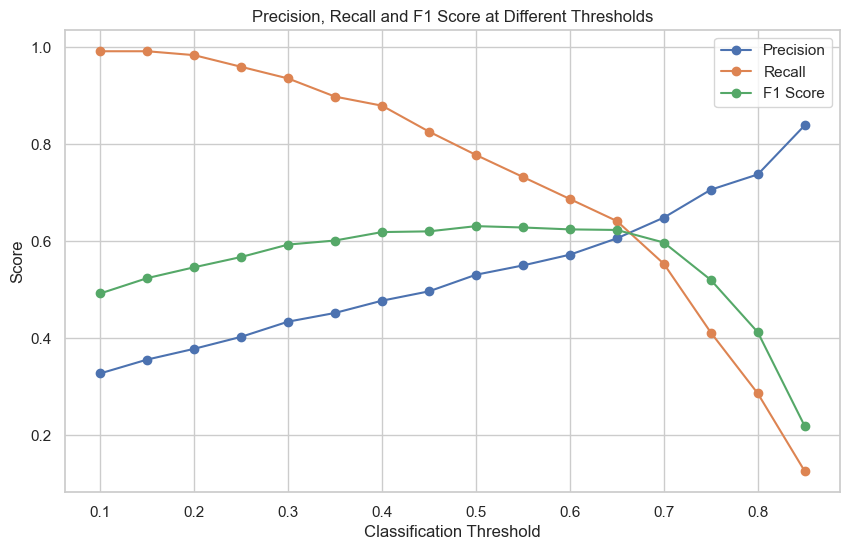

In [45]:
plt.figure(figsize=(10, 6))

plt.plot(threshold_results_df["Threshold"], threshold_results_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["F1 Score"], marker="o", label="F1 Score")

plt.title("Precision, Recall and F1 Score at Different Thresholds")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

## Precision-Recall Trade-Off

The threshold tuning chart shows the expected trade-off between precision and recall. As the classification threshold increases, the model becomes more selective in predicting churn. This causes precision to rise because fewer low-risk customers are incorrectly flagged, but recall falls because more actual churners are missed.

The F1-score remains strongest around the middle threshold range, suggesting that neither very low nor very high thresholds are ideal. Very low thresholds identify almost all churners but create too many false positives, while very high thresholds improve precision but miss too many customers who actually churn.

A threshold around **0.65** provides a practical compromise between business cost and churn detection.

In [46]:
threshold_results_df[threshold_results_df["Precision"] >= 0.60].sort_values("Recall", ascending=False)

,Threshold,Accuracy,Precision,Recall,F1 Score
11,0.65,0.794180,0.606061,0.641711,0.623377
12,0.70,0.801987,0.648903,0.553476,0.597403
13,0.75,0.798439,0.706422,0.411765,0.520270
14,0.80,0.783534,0.737931,0.286096,0.412331
15,0.85,0.761533,0.839286,0.125668,0.218605


In [47]:
selected_threshold = 0.65  # change this based on your output

y_pred_adjusted = (y_proba_tuned_rf >= selected_threshold).astype(int)

adjusted_results = {
    "Model": "Random Forest - Adjusted Threshold",
    "Threshold": selected_threshold,
    "Accuracy": accuracy_score(y_test, y_pred_adjusted),
    "Precision": precision_score(y_test, y_pred_adjusted),
    "Recall": recall_score(y_test, y_pred_adjusted),
    "F1 Score": f1_score(y_test, y_pred_adjusted),
    "ROC-AUC": roc_auc_score(y_test, y_proba_tuned_rf)
}

pd.DataFrame([adjusted_results])

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest - Adjusted Threshold,0.65,0.79418,0.606061,0.641711,0.623377,0.849797


###

### In real retention campaigns, companies often do not target everyone predicted as churn. Instead, they target the top 10%, 20%, or 30% highest-risk customers.

### That can improve campaign efficiency.

In [48]:
test_predictions = X_test.copy()

test_predictions["actual_churn"] = y_test.values
test_predictions["churn_probability"] = y_proba_final

test_predictions["risk_rank"] = test_predictions["churn_probability"].rank(
    ascending=False,
    method="first"
)

top_20_cutoff = int(len(test_predictions) * 0.20)

top_20_customers = test_predictions.sort_values(
    "churn_probability",
    ascending=False
).head(top_20_cutoff)

top_20_precision = top_20_customers["actual_churn"].mean()

print(f"Precision among top 20% highest-risk customers: {top_20_precision:.2%}")
print(f"Customers targeted: {len(top_20_customers)}")
print(f"Actual churners captured: {top_20_customers['actual_churn'].sum()}")

Precision among top 20% highest-risk customers: 67.97%
Customers targeted: 281
Actual churners captured: 191


## Top 20% Highest-Risk Customer Targeting

In addition to threshold tuning, customers were ranked by predicted churn probability. This is useful because businesses often have limited retention budgets and may only be able to target the highest-risk customers.

When targeting the top **20%** highest-risk customers in the test set, the model selected **281 customers**. Among these customers, **191 actually churned**, giving a precision of **67.97%**.

This is a strong business result because it shows that the model can identify a concentrated group of high-risk customers. Instead of applying retention actions broadly across the entire customer base, the company can focus on the customers most likely to leave.

This approach helps reduce unnecessary retention spending and makes the model more practical for campaign planning.

###

## Trying out XGBoost 

In [49]:
from xgboost import XGBClassifier

In [50]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        ))
    ]
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

xgb_results = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1 Score": f1_score(y_test, y_pred_xgb),
    "ROC-AUC": roc_auc_score(y_test, y_proba_xgb)
}

pd.DataFrame([xgb_results])

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.800568,0.648562,0.542781,0.590975,0.853296


In [51]:
xgb_results_df = pd.DataFrame([xgb_results])

all_model_results_with_xgb = pd.concat(
    [all_model_results, xgb_results_df],
    ignore_index=True
)

all_model_results_with_xgb.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
5,XGBoost,0.800568,0.648562,0.542781,0.590975,0.853296
2,Gradient Boosting,0.804116,0.660131,0.540107,0.594118,0.852592
4,Tuned Gradient Boosting,0.801278,0.653595,0.534759,0.588235,0.851719
1,Random Forest,0.767211,0.544402,0.754011,0.632287,0.851372
3,Tuned Random Forest,0.758694,0.531022,0.778075,0.631236,0.849797
0,Logistic Regression,0.801987,0.642643,0.572193,0.605375,0.848942


In [52]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            eval_metric="logloss",
            random_state=42
        ))
    ]
)

xgb_param_grid = {
    "model__n_estimators": [200, 300],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train, y_train)

print("Best XGBoost parameters:")
print(xgb_grid_search.best_params_)

print("\nBest cross-validation F1:")
print(xgb_grid_search.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best XGBoost parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 200, 'model__subsample': 0.8}

Best cross-validation F1:
0.6194067799948368


In [53]:
tuned_xgb_model = xgb_grid_search.best_estimator_

y_pred_tuned_xgb = tuned_xgb_model.predict(X_test)
y_proba_tuned_xgb = tuned_xgb_model.predict_proba(X_test)[:, 1]

tuned_xgb_results = {
    "Model": "Tuned XGBoost",
    "Accuracy": accuracy_score(y_test, y_pred_tuned_xgb),
    "Precision": precision_score(y_test, y_pred_tuned_xgb),
    "Recall": recall_score(y_test, y_pred_tuned_xgb),
    "F1 Score": f1_score(y_test, y_pred_tuned_xgb),
    "ROC-AUC": roc_auc_score(y_test, y_proba_tuned_xgb)
}

tuned_xgb_results_df = pd.DataFrame([tuned_xgb_results])

all_model_results_with_xgb = pd.concat(
    [all_model_results_with_xgb, tuned_xgb_results_df],
    ignore_index=True
)

all_model_results_with_xgb.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
6,Tuned XGBoost,0.808375,0.663522,0.564171,0.609827,0.855288
5,XGBoost,0.800568,0.648562,0.542781,0.590975,0.853296
2,Gradient Boosting,0.804116,0.660131,0.540107,0.594118,0.852592
4,Tuned Gradient Boosting,0.801278,0.653595,0.534759,0.588235,0.851719
1,Random Forest,0.767211,0.544402,0.754011,0.632287,0.851372
3,Tuned Random Forest,0.758694,0.531022,0.778075,0.631236,0.849797
0,Logistic Regression,0.801987,0.642643,0.572193,0.605375,0.848942


In [54]:
xgb_threshold_results = []

thresholds = np.arange(0.1, 0.9, 0.05)

for threshold in thresholds:
    y_pred_threshold = (y_proba_tuned_xgb >= threshold).astype(int)
    
    xgb_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1 Score": f1_score(y_test, y_pred_threshold)
    })

xgb_threshold_results_df = pd.DataFrame(xgb_threshold_results)

xgb_threshold_results_df

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.10,0.640170,0.421857,0.959893,0.586122
1,0.15,0.689851,0.457375,0.903743,0.607367
2,0.20,0.715401,0.479638,0.850267,0.613308
3,0.25,0.743080,0.510135,0.807487,0.625259
4,0.30,0.760114,0.533582,0.764706,0.628571
5,0.35,0.778566,0.565401,0.716578,0.632075
6,0.40,0.793471,0.597190,0.681818,0.636704
7,0.45,0.798439,0.619681,0.622995,0.621333
8,0.50,0.808375,0.663522,0.564171,0.609827
9,0.55,0.806955,0.705645,0.467914,0.562701


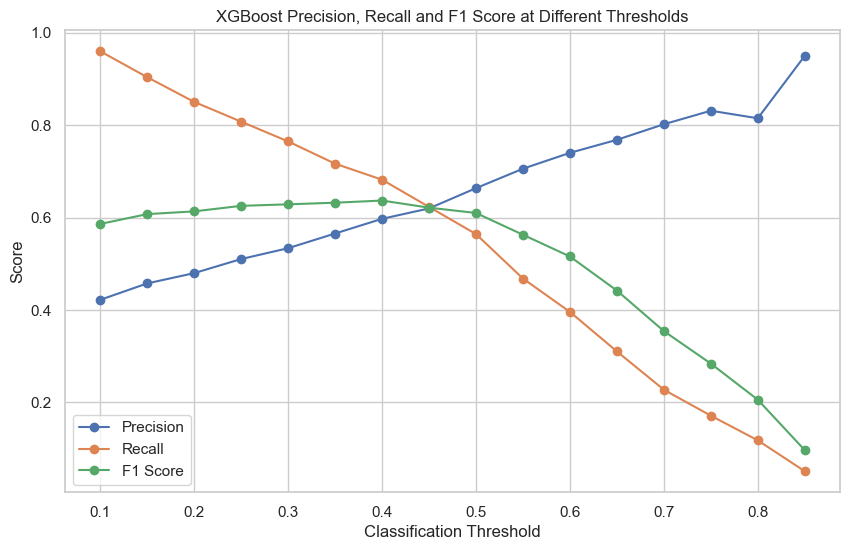

In [55]:
plt.figure(figsize=(10, 6))

plt.plot(xgb_threshold_results_df["Threshold"], xgb_threshold_results_df["Precision"], marker="o", label="Precision")
plt.plot(xgb_threshold_results_df["Threshold"], xgb_threshold_results_df["Recall"], marker="o", label="Recall")
plt.plot(xgb_threshold_results_df["Threshold"], xgb_threshold_results_df["F1 Score"], marker="o", label="F1 Score")

plt.title("XGBoost Precision, Recall and F1 Score at Different Thresholds")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

In [56]:
xgb_test_predictions = X_test.copy()

xgb_test_predictions["actual_churn"] = y_test.values
xgb_test_predictions["churn_probability"] = y_proba_tuned_xgb

top_20_cutoff = int(len(xgb_test_predictions) * 0.20)

xgb_top_20_customers = xgb_test_predictions.sort_values(
    "churn_probability",
    ascending=False
).head(top_20_cutoff)

xgb_top_20_precision = xgb_top_20_customers["actual_churn"].mean()

print(f"XGBoost precision among top 20% highest-risk customers: {xgb_top_20_precision:.2%}")
print(f"Customers targeted: {len(xgb_top_20_customers)}")
print(f"Actual churners captured: {xgb_top_20_customers['actual_churn'].sum()}")

XGBoost precision among top 20% highest-risk customers: 69.04%
Customers targeted: 281
Actual churners captured: 194


In [57]:
y_proba_tuned_xgb = tuned_xgb_model.predict_proba(X_test)[:, 1]

selected_threshold = 0.45

y_pred_xgb_045 = (y_proba_tuned_xgb >= selected_threshold).astype(int)

xgb_045_results = {
    "Model": "Tuned XGBoost - Threshold 0.45",
    "Threshold": selected_threshold,
    "Accuracy": accuracy_score(y_test, y_pred_xgb_045),
    "Precision": precision_score(y_test, y_pred_xgb_045),
    "Recall": recall_score(y_test, y_pred_xgb_045),
    "F1 Score": f1_score(y_test, y_pred_xgb_045),
    "ROC-AUC": roc_auc_score(y_test, y_proba_tuned_xgb)
}

pd.DataFrame([xgb_045_results])

,Model,Threshold,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned XGBoost - Threshold 0.45,0.45,0.798439,0.619681,0.622995,0.621333,0.855288


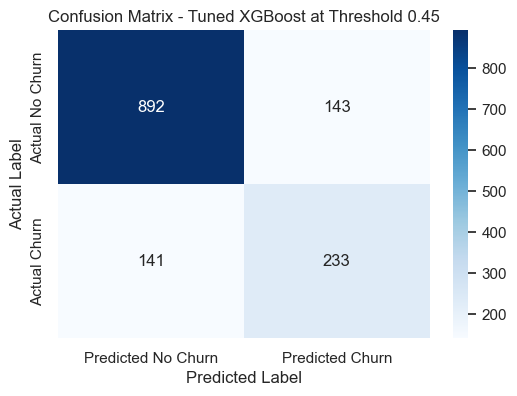

In [58]:
cm_xgb_045 = confusion_matrix(y_test, y_pred_xgb_045)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_xgb_045,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted No Churn", "Predicted Churn"],
    yticklabels=["Actual No Churn", "Actual Churn"]
)

plt.title("Confusion Matrix - Tuned XGBoost at Threshold 0.45")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [59]:
print(classification_report(y_test, y_pred_xgb_045))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1035
           1       0.62      0.62      0.62       374

    accuracy                           0.80      1409
   macro avg       0.74      0.74      0.74      1409
weighted avg       0.80      0.80      0.80      1409



## Final Threshold Selection: Tuned XGBoost at 0.45

The tuned XGBoost model was evaluated at a classification threshold of **0.45** to improve the balance between precision and recall.

At this threshold, the model achieved an accuracy of **79.84%**, precision of **61.97%**, recall of **62.30%**, F1-score of **0.621**, and ROC-AUC of **0.855**.

The confusion matrix shows that the model correctly identified **233 churned customers** and correctly classified **892 retained customers**. It also produced **143 false positives**, where retained customers were incorrectly flagged as churn risks, and **141 false negatives**, where actual churned customers were missed.

This threshold provides a balanced trade-off between identifying churned customers and controlling unnecessary retention spending. Compared with the default threshold of 0.50, the 0.45 threshold improves recall and F1-score while maintaining reasonable precision.

Therefore, the tuned XGBoost model with a threshold of **0.45** is selected as the final classification setup for this project.

## Business Interpretation

The final model is suitable for a balanced retention campaign. A precision of **61.97%** means that around six out of ten customers flagged as churn risks actually churned. A recall of **62.30%** means the model identified around six out of ten actual churners.

This balance is useful because the company wants to detect at-risk customers without creating excessive false positives. If retention actions are low-cost, the company could lower the threshold further to capture more churners. If retention actions are expensive, the company could increase the threshold to improve precision.

For this project, threshold **0.45** provides a practical middle ground between customer retention coverage and campaign cost control.

The final stage of the project focuses on translating model outputs into business action. Instead of stopping at model accuracy, the churn probabilities are used to rank customers by risk, estimate expected revenue at risk, and identify the customers who should be prioritised for retention campaigns.

###

## ROC Curve for our final tuned XGBoost model 

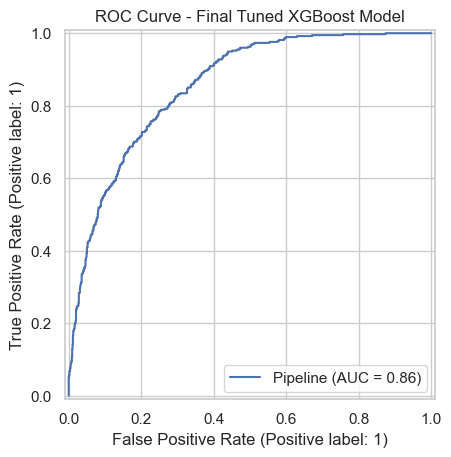

In [60]:
RocCurveDisplay.from_estimator(tuned_xgb_model, X_test, y_test)

plt.title("ROC Curve - Final Tuned XGBoost Model")
plt.show()

### ROC Curve Interpretation

The ROC curve evaluates how well the final tuned XGBoost model separates churned customers from retained customers across different classification thresholds.

The model achieved a ROC-AUC score of approximately **0.86**, indicating strong discriminatory power. This means the model is effective at assigning higher churn probabilities to customers who are more likely to leave.

This is important for the business use case because churn probabilities can be used to rank customers by risk. Rather than relying only on a binary churn/no-churn prediction, the company can prioritise customers with the highest estimated churn probability for retention action.

## Feature Importance

In [61]:
# Extracting fitted preprocessor
fitted_preprocessor = tuned_xgb_model.named_steps["preprocessor"]

# Numerical feature names
num_feature_names = numeric_features

# One-hot encoded categorical feature names
cat_feature_names = (
    fitted_preprocessor
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
    .tolist()
)

# Combining feature names
all_feature_names = num_feature_names + cat_feature_names

# Extracting feature importance values from XGBoost
feature_importances = tuned_xgb_model.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": feature_importances
}).sort_values("Importance", ascending=False)

feature_importance_df.head(20)

,Feature,Importance
38,contract_Month-to-month,0.275381
20,online_security_No,0.167678
18,internet_service_Fiber optic,0.087419
29,tech_support_No,0.084979
45,payment_method_Electronic check,0.053336
10,dependents_No,0.039612
40,contract_Two year,0.030166
0,tenure_months,0.028649
42,paperless_billing_Yes,0.023475
23,online_backup_No,0.022633


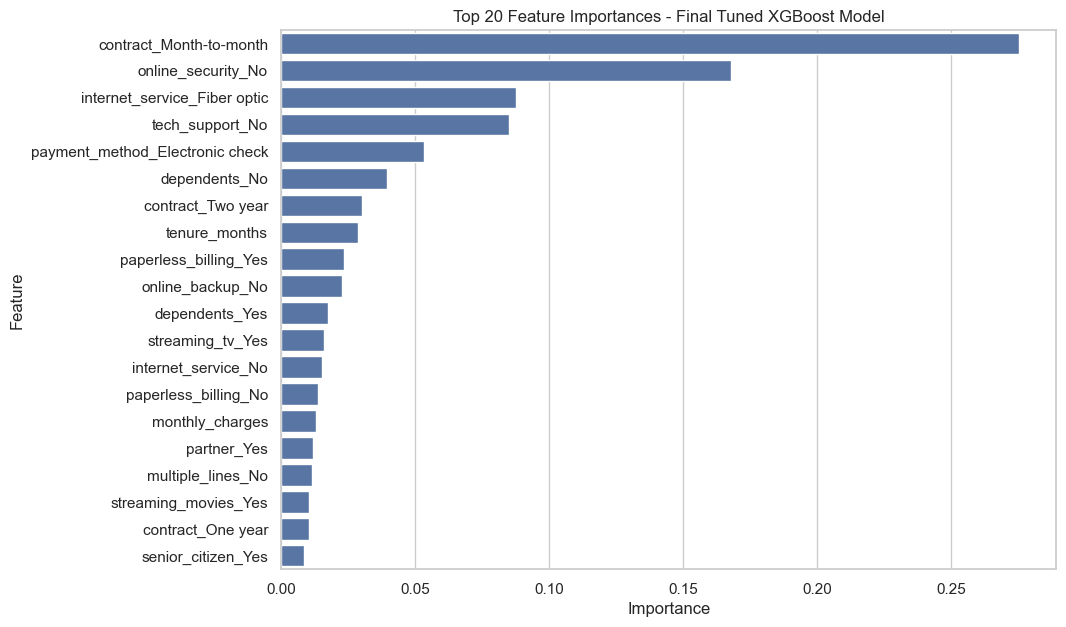

In [62]:
top_20_features = feature_importance_df.head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_20_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importances - Final Tuned XGBoost Model")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Feature Importance Interpretation

The feature importance results show which variables contributed most to the final tuned XGBoost model’s churn predictions.

The most important feature is **month-to-month contract**, which strongly supports the earlier SQL finding that month-to-month customers have the highest churn rate. Other highly important features include **no online security**, **fiber optic internet service**, **no tech support**, and **electronic check payment method**.

These results are consistent with the business analysis from Notebook 1. Customers are more likely to churn when they have flexible contracts, use fiber optic service, pay by electronic check, and do not subscribe to support or security-related add-ons.

This consistency strengthens the project because the machine learning model is not acting as a black box. Its most important predictive features align with the patterns found through SQL analysis and EDA.

Feature importance should not be interpreted as direct causation. However, it does show which customer attributes were most useful for predicting churn.

### Key Feature Importance Findings

The top predictive features suggest that churn risk is driven mainly by contract flexibility, service type, support coverage, payment behaviour, and customer relationship characteristics.

The strongest churn indicators include:

- **Contract_Month-to-month**
- **Online_Security_No**
- **Internet_Service_Fiber optic**
- **Tech_Support_No**
- **Payment_Method_Electronic check**
- **Dependents_No**
- **Tenure_Months**
- **Monthly_Charges**

From a business perspective, this suggests that customers are especially vulnerable to churn when they have low contractual commitment, limited support services, and potentially higher service expectations or costs.

These findings can guide targeted retention actions, such as encouraging longer-term contracts, bundling tech support or online security, improving the fiber optic customer experience, and reviewing billing/payment journeys for electronic check users.

In [63]:
feature_importance_df.to_csv(
    "../data/processed/final_xgboost_feature_importance.csv",
    index=False
)

print("Feature importance table saved successfully.")

Feature importance table saved successfully.


####

## Customer-level Churn Probabilities 

The final tuned XGBoost model generated a churn probability score for each customer in the test set. These probabilities represent the estimated likelihood that a customer will churn.

The highest-risk customers show very consistent characteristics. Many of them are on **month-to-month contracts**, use **fiber optic internet**, pay by **electronic check**, have **short tenure**, and do not subscribe to services such as **online security** or **tech support**.

This pattern is consistent with the SQL analysis, feature importance results, and modelling-focused EDA. It suggests that the model is learning meaningful business patterns rather than random noise.

Customer-level churn probabilities are useful because they allow the company to rank customers by risk. This is more practical than only predicting churn as yes or no, because retention teams can focus first on customers with the highest churn probability.

In [64]:
selected_threshold = 0.45

# Generate final adjusted predictions
y_pred_final = (y_proba_tuned_xgb >= selected_threshold).astype(int)

# Create prediction dataframe
customer_predictions = X_test.copy()

customer_predictions["customerid"] = df.loc[X_test.index, "customerid"].values
customer_predictions["actual_churn"] = y_test.values
customer_predictions["predicted_churn"] = y_pred_final
customer_predictions["churn_probability"] = y_proba_tuned_xgb

# Reorder key columns
key_cols = [
    "customerid",
    "actual_churn",
    "predicted_churn",
    "churn_probability"
]

remaining_cols = [col for col in customer_predictions.columns if col not in key_cols]

customer_predictions = customer_predictions[key_cols + remaining_cols]

customer_predictions

,customerid,actual_churn,predicted_churn,churn_probability,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,cltv
2196,4376-KFVRS,0,0,0.047132,Male,No,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,4842
3549,2754-SDJRD,0,1,0.723292,Female,Yes,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,5157
3515,9917-KWRBE,0,0,0.112982,Female,No,Yes,No,41,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,2894
5162,0365-GXEZS,0,0,0.435736,Male,No,Yes,No,18,Yes,No,Fiber optic,No,No,Yes,Yes,No,No,Month-to-month,No,Electronic check,78.20,1468.75,2831
4642,9385-NXKDA,0,0,0.034452,Female,No,Yes,No,72,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,4324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5660,5204-HMGYF,0,0,0.014036,Female,No,Yes,Yes,49,Yes,No,DSL,Yes,Yes,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,87.20,4345.00,4567
5150,9950-MTGYX,0,0,0.006043,Male,No,Yes,Yes,28,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),20.30,487.95,2948
4708,3675-EQOZA,0,0,0.138709,Male,No,No,No,5,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),20.65,93.55,5597
5381,3646-ITDGM,0,0,0.017296,Female,No,No,No,56,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.70,1051.90,4831


## Top 20 high-risk customers

In [65]:
customer_predictions.sort_values(
    "churn_probability",
    ascending=False
).head(20)

,customerid,actual_churn,predicted_churn,churn_probability,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,cltv
886,5178-LMXOP,1,1,0.930479,Male,Yes,Yes,No,1,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.10,95.10,5795
1818,0295-PPHDO,1,1,0.910156,Male,No,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.45,95.45,5962
590,7181-BQYBV,1,1,0.904999,Female,No,Yes,No,1,Yes,Yes,Fiber optic,Yes,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,102.45,102.45,4811
1203,1069-XAIEM,1,1,0.893633,Female,Yes,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.05,85.05,2975
1681,8884-ADFVN,1,1,0.879303,Male,Yes,Yes,No,7,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,101.95,700.85,2016
684,6861-XWTWQ,1,1,0.879303,Male,Yes,Yes,No,7,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.25,665.45,2487
158,0970-ETWGE,1,1,0.875695,Male,No,No,No,1,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,89.55,89.55,4996
1756,9248-OJYKK,1,1,0.875506,Male,Yes,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,76.45,76.45,3763
1827,1400-MMYXY,1,1,0.871083,Male,Yes,Yes,No,3,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.90,334.65,2715
598,7180-PISOG,1,1,0.870105,Male,No,Yes,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,74.50,74.50,5554


### Insight from Highest-Risk Customers

The sample of customers with the highest churn probabilities shows that the model is identifying a clear high-risk profile.

Several top-ranked customers have churn probabilities above **80%**, and most share the following characteristics:

- Very short tenure, often only 1 to 7 months
- Month-to-month contract
- Fiber optic internet service
- Electronic check payment method
- No tech support
- No online security
- Relatively high monthly charges

This confirms that early-stage, high-charge fiber optic customers with limited support coverage are a major churn-risk group.

From a business perspective, these customers should be prioritised for proactive interventions such as onboarding support, technical service check-ins, billing reassurance, or targeted retention offers.

In [66]:
customer_predictions.to_csv(
    "../data/processed/customer_churn_probability_scores.csv",
    index=False
)

print("Customer churn probability scores saved successfully.")

Customer churn probability scores saved successfully.


###

## Retention-priority framework

A retention priority framework was created to move beyond churn prediction and support business decision-making.

The framework combines three key elements:

1. **Churn probability** — how likely the customer is to leave.
2. **Monthly charges** — the recurring revenue associated with the customer.
3. **CLTV** — the customer’s estimated lifetime value.

Expected monthly revenue at risk was calculated as:

`churn_probability × monthly_charges`

Retention priority score was calculated as:

`churn_probability × CLTV`

This ensures that customers are not prioritised based only on churn risk. Instead, the framework highlights customers who are both likely to churn and financially valuable.

#####

#### Creating Risk Segments

Customers are grouped into risk segments based on their predicted churn probability:

- High Risk: churn probability of 70% or higher
- Medium Risk: churn probability between 45% and 70%
- Low Risk: churn probability below 45%


In [67]:
def assign_risk_segment(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.45:
        return "Medium Risk"
    else:
        return "Low Risk"

customer_predictions["risk_segment"] = customer_predictions["churn_probability"].apply(assign_risk_segment)

#### Revenue at Risk

In [69]:
# Monthly revenue at risk based on churn probability
customer_predictions["expected_monthly_revenue_at_risk"] = (
    customer_predictions["churn_probability"] * customer_predictions["monthly_charges"]
)

# Expected annual revenue at risk
customer_predictions["expected_annual_revenue_at_risk"] = (
    customer_predictions["expected_monthly_revenue_at_risk"] * 12
)

#### Retention Priority Score

In [70]:
# Retention priority score using churn probability and CLTV
customer_predictions["retention_priority_score"] = (
    customer_predictions["churn_probability"] * customer_predictions["cltv"]
)

#### Creating Priority Groups

In [71]:
customer_predictions["priority_group"] = pd.qcut(
    customer_predictions["retention_priority_score"],
    q=4,
    labels=["Low Priority", "Medium Priority", "High Priority", "Critical Priority"]
)

#### Top Customers

In [72]:
top_priority_customers = customer_predictions.sort_values(
    "retention_priority_score",
    ascending=False
)

top_priority_customers[
    [
        "customerid",
        "churn_probability",
        "risk_segment",
        "monthly_charges",
        "cltv",
        "expected_monthly_revenue_at_risk",
        "retention_priority_score",
        "priority_group"
    ]
].head(20)

,customerid,churn_probability,risk_segment,monthly_charges,cltv,expected_monthly_revenue_at_risk,retention_priority_score,priority_group
1818,0295-PPHDO,0.910156,High Risk,95.45,5962,86.874374,5426.349075,Critical Priority
886,5178-LMXOP,0.930479,High Risk,95.10,5795,88.488558,5392.126093,Critical Priority
6213,1628-BIZYP,0.842754,High Risk,85.00,5754,71.634096,4849.206896,Critical Priority
598,7180-PISOG,0.870105,High Risk,74.50,5554,64.822825,4832.563326,Critical Priority
964,3716-BDVDB,0.814475,High Risk,69.10,5795,56.280231,4719.883315,Critical Priority
145,2865-TCHJW,0.801223,High Risk,89.20,5808,71.469127,4653.505491,Critical Priority
731,6023-YEBUP,0.867103,High Risk,100.95,5351,87.534070,4639.869325,Critical Priority
753,7409-KIUTL,0.834938,High Risk,71.00,5345,59.280580,4462.742281,Critical Priority
158,0970-ETWGE,0.875695,High Risk,89.55,4996,78.418518,4374.973958,Critical Priority
2567,6630-UJZMY,0.830302,High Risk,83.25,5251,69.122632,4359.915176,Critical Priority


### Top Priority Customer Interpretation

The top 20 priority customers all fall into the **High Risk** and **Critical Priority** categories. These customers have high churn probabilities and high customer lifetime value, making them the most important customers for proactive retention.

For example, several customers have churn probabilities above **80%** and CLTV values above **5000**. This means that losing these customers would represent a meaningful financial risk. It's also important to note here that these customers are paying more than the average monthly charge which is around **$64** and the average CLTV value is **4400**.

The top priority table is especially useful for business action because it provides a customer-level retention list. A retention team could use this output to decide which customers should receive personalised outreach, loyalty offers, technical support intervention, or contract upgrade incentives.

In [73]:
# Saving the final output

customer_predictions.to_csv(
    "../data/processed/customer_retention_priority_scores.csv",
    index=False
)

print("Customer retention priority scores saved successfully.")

Customer retention priority scores saved successfully.


####

## Priority Segment Summary

In [75]:
priority_summary = (
    customer_predictions
    .groupby("priority_group")
    .agg(
        customers=("customerid", "count"),
        avg_churn_probability=("churn_probability", "mean"),
        avg_monthly_charge=("monthly_charges", "mean"),
        avg_cltv=("cltv", "mean"),
        total_expected_monthly_revenue_at_risk=("expected_monthly_revenue_at_risk", "sum"),
        total_expected_annual_revenue_at_risk=("expected_annual_revenue_at_risk", "sum")
    )
    .reset_index()
)

priority_summary

/var/folders/tx/jscqmpxn1p9g0dc18w1761wm0000gn/T/ipykernel_72505/2018751760.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("priority_group")


,priority_group,customers,avg_churn_probability,avg_monthly_charge,avg_cltv,total_expected_monthly_revenue_at_risk,total_expected_annual_revenue_at_risk
0,Low Priority,353,0.019716,46.463031,4530.555241,324.371312,3892.455740
1,Medium Priority,352,0.098268,63.464631,4451.650568,2167.697778,26012.373337
2,High Priority,352,0.342689,68.726420,3987.693182,8388.172263,100658.067162
3,Critical Priority,352,0.602923,77.751420,4570.014205,16720.687346,200648.248150


### Priority Segment Summary

The priority segment summary shows a clear increase in risk and financial exposure across the four priority groups.

The **Low Priority** group has an average churn probability of only **1.97%** and total expected monthly revenue at risk of approximately **USD 324**.

The **Medium Priority** group has an average churn probability of **9.83%** and expected monthly revenue at risk of approximately **USD 2,168**.

The **High Priority** group has an average churn probability of **34.27%** and expected monthly revenue at risk of approximately **USD 8,388**.

The **Critical Priority** group has the highest average churn probability at **60.29%** and the highest expected monthly revenue at risk at approximately **USD 16,721** per month.

This shows that revenue risk is heavily concentrated in the Critical Priority group. Although each priority group contains a similar number of customers, the financial risk increases sharply as churn probability and customer value rise.

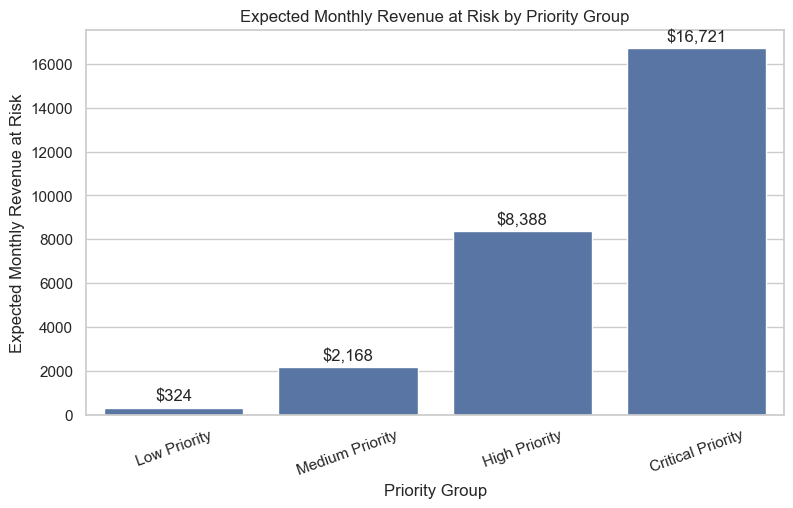

In [76]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=priority_summary,
    x="priority_group",
    y="total_expected_monthly_revenue_at_risk"
)

plt.title("Expected Monthly Revenue at Risk by Priority Group")
plt.xlabel("Priority Group")
plt.ylabel("Expected Monthly Revenue at Risk")
plt.xticks(rotation=20)

# Add currency-style labels
ax.bar_label(
    ax.containers[0],
    labels=[
        f"${value:,.0f}" 
        for value in priority_summary["total_expected_monthly_revenue_at_risk"]
    ],
    padding=3
)

plt.show()

### Revenue-at-Risk Interpretation

The expected monthly revenue at risk chart shows that the **Critical Priority** group contributes the largest amount of expected revenue risk, with approximately **USD 16,721** at risk per month. This is almost double the expected monthly revenue at risk in the High Priority group and far higher than the Medium and Low Priority groups.

This finding is important because it helps the business allocate retention resources efficiently. Instead of targeting all customers equally, the company can focus on the Critical and High Priority groups, where the potential financial impact of churn is greatest.

The chart also supports a tiered retention strategy. Critical Priority customers may justify personalised or higher-cost interventions, while Medium Priority customers may receive lower-cost digital engagement campaigns.

In [77]:
priority_summary.to_csv(
    "../data/processed/retention_priority_summary.csv",
    index=False
)

print("Retention priority summary saved successfully.")

Retention priority summary saved successfully.


###

## Business Recommendations

Based on the model outputs and retention priority framework, the company should focus on the following actions:

1. **Prioritise Critical Priority customers**
   
   Customers in the Critical Priority group have the highest combination of churn probability and customer value. These customers should receive proactive retention outreach first.

2. **Target month-to-month customers with contract upgrade incentives**
   
   Month-to-month contract status was the most important predictive feature. The company could offer loyalty discounts, bundled services, or limited-time incentives to encourage these customers to move to one-year or two-year contracts.

3. **Improve support coverage for high-risk internet customers**
   
   Customers without tech support or online security are more likely to churn. The company could offer discounted support bundles or proactive technical check-ins to high-risk customers.

4. **Investigate fiber optic customer experience**
   
   Fiber optic service is one of the most important churn predictors. The company should investigate whether these customers are experiencing pricing concerns, service reliability issues, or competitor pressure.

5. **Review electronic check payment customers**
   
   Electronic check payment is an important churn predictor. The company could encourage these customers to move to automatic payment methods through convenience messaging or small incentives.

6. **Focus on early-tenure customers**
   
   Short-tenure customers appear frequently among the highest-risk customers. The company should improve onboarding, first-month communication, and early customer support to reduce churn during the first year.

###

## Final Project Summary

This project developed an end-to-end customer churn analytics solution using SQL, Python, machine learning, and business prioritisation.

The SQL and EDA analysis identified important churn patterns across contract type, payment method, internet service, tenure, support services, and customer demographics. The modelling stage compared multiple classification models, including Logistic Regression, Random Forest, Gradient Boosting, and XGBoost.

The final selected model was the **tuned XGBoost classifier** with an adjusted threshold of **0.45**. This model achieved a strong ROC-AUC score of approximately **0.86** and provided a balanced trade-off between precision and recall.

The project then moved beyond prediction by generating customer-level churn probabilities, expected revenue at risk, and retention priority scores. This allowed customers to be segmented into Low, Medium, High, and Critical Priority groups.

The final output gives the business a practical retention framework that can be used to prioritise high-risk, high-value customers and design targeted retention strategies.

###

## Conclusion

The final model and retention framework show how machine learning can be used not only to predict churn, but also to support practical business decisions. By combining churn probability with customer value, the company can focus retention resources on the customers where intervention is likely to have the highest financial impact.